# Installing Packages

In [4]:
!pip -q install medmnist torchmetrics[image] torch-fidelity scikit-learn tqdm

# Importing all libraries, seed, folders

In [5]:
import os
import math
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchvision.utils import make_grid

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from tqdm.auto import tqdm
from torchmetrics.image.fid import FrechetInceptionDistance

import medmnist
from medmnist import INFO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs("outputs/part1", exist_ok=True)
os.makedirs("outputs/bloodmnist", exist_ok=True)
os.makedirs("outputs/cicids", exist_ok=True)
os.makedirs("outputs/quickdraw", exist_ok=True)
os.makedirs("data/cicids", exist_ok=True)
os.makedirs("data/quickdraw", exist_ok=True)

Device: cpu


# Utility Functions

In [6]:
def save_loss_plot(g_losses, d_losses, title, save_path):
    plt.figure(figsize=(8, 4))
    plt.plot(g_losses, label="Generator Loss")
    plt.plot(d_losses, label="Discriminator Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

def save_or_show_grid(images, title="", save_path=None, nrow=4, normalize=True, cmap=None):
    grid = make_grid(images, nrow=nrow, normalize=normalize)
    arr = grid.permute(1, 2, 0).detach().cpu().numpy()
    plt.figure(figsize=(6, 6))
    if arr.shape[-1] == 1:
        plt.imshow(arr.squeeze(), cmap=cmap or "gray")
    else:
        plt.imshow(arr)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

def denorm_01(x):
    return (x.clamp(-1, 1) + 1.0) / 2.0

@torch.no_grad()
def sample_generator_images(generator, latent_dim, n, channels, device):
    generator.eval()
    z = torch.randn(n, latent_dim, 1, 1, device=device)
    fake = generator(z).detach().cpu()
    generator.train()
    return fake

def prepare_for_fid(images, is_rgb=True):
    x = denorm_01(images)
    if not is_rgb:
        x = x.repeat(1, 3, 1, 1)
    x = F.interpolate(x, size=(299, 299), mode="bilinear", align_corners=False)
    x = (x * 255.0).clamp(0, 255).to(torch.uint8)
    return x

@torch.no_grad()
def compute_fid(generator, real_loader, latent_dim, device, is_rgb=True, max_batches=10):
    metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    generator.eval()

    count = 0
    for batch in real_loader:
        real = batch[0].to(device)
        metric.update(prepare_for_fid(real, is_rgb=is_rgb), real=True)

        bs = real.size(0)
        z = torch.randn(bs, latent_dim, 1, 1, device=device)
        fake = generator(z)
        metric.update(prepare_for_fid(fake, is_rgb=is_rgb), real=False)

        count += 1
        if count >= max_batches:
            break

    fid_value = metric.compute().item()
    generator.train()
    return fid_value

## Part 1: Synthetic Data GAN

In this section, a GAN is implemented on simple 2D distributions to understand the fundamental adversarial training process.

A sine-wave distribution is first reproduced, followed by a more complex mixture of Gaussians. The performance of the baseline architecture is then compared to a modified architecture.

# Generating Synthetic Data

In [7]:
def make_sine_data(n_samples=5000):
    x = np.random.uniform(-math.pi, math.pi, n_samples)
    y = np.sin(x) + 0.1 * np.random.randn(n_samples)
    return np.stack([x, y], axis=1).astype(np.float32)

def make_mog_data(n_samples=5000, num_modes=8, radius=2.5, std=0.15):
    centers = []
    for i in range(num_modes):
        angle = 2 * math.pi * i / num_modes
        centers.append((radius * math.cos(angle), radius * math.sin(angle)))

    samples = []
    for _ in range(n_samples):
        cx, cy = centers[np.random.randint(num_modes)]
        point = np.array([cx, cy]) + np.random.randn(2) * std
        samples.append(point)

    return np.array(samples, dtype=np.float32)

def get_2d_loader(data, batch_size=128):
    tensor = torch.tensor(data, dtype=torch.float32)
    dataset = TensorDataset(tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

def plot_2d_data(data, title, save_path=None):
    plt.figure(figsize=(5, 5))
    plt.scatter(data[:, 0], data[:, 1], s=5, alpha=0.5)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

# MLP GAN Models

In [8]:
class MLPGenerator(nn.Module):
    def __init__(self, latent_dim=16, output_dim=2, hidden_dims=(128, 256), activation="leakyrelu", batch_norm=True):
        super().__init__()
        layers = []
        in_dim = latent_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, hidden_dim))
            if batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            if activation.lower() == "relu":
                layers.append(nn.ReLU(inplace=True))
            else:
                layers.append(nn.LeakyReLU(0.2, inplace=True))
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, z):
        return self.model(z)

class MLPDiscriminator(nn.Module):
    def __init__(self, input_dim=2, hidden_dims=(256, 128), activation="leakyrelu"):
        super().__init__()
        layers = []
        in_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, hidden_dim))
            if activation.lower() == "relu":
                layers.append(nn.ReLU(inplace=True))
            else:
                layers.append(nn.LeakyReLU(0.2, inplace=True))
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, 1))
        layers.append(nn.Sigmoid())
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Training Loop

In [9]:
def train_mlp_gan(generator, discriminator, dataloader, latent_dim=16, epochs=200, lr=2e-4, device="cpu"):
    generator = generator.to(device)
    discriminator = discriminator.to(device)

    criterion = nn.BCELoss()
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    g_losses, d_losses = [], []

    for epoch in range(epochs):
        g_epoch, d_epoch = 0.0, 0.0

        for batch in dataloader:
            real = batch[0].to(device)
            bs = real.size(0)

            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            z = torch.randn(bs, latent_dim, device=device)
            fake = generator(z)

            d_real = discriminator(real)
            d_fake = discriminator(fake.detach())

            loss_d_real = criterion(d_real, real_labels)
            loss_d_fake = criterion(d_fake, fake_labels)
            loss_d = loss_d_real + loss_d_fake

            opt_d.zero_grad()
            loss_d.backward()
            opt_d.step()

            z = torch.randn(bs, latent_dim, device=device)
            fake = generator(z)
            d_fake = discriminator(fake)

            loss_g = criterion(d_fake, real_labels)

            opt_g.zero_grad()
            loss_g.backward()
            opt_g.step()

            g_epoch += loss_g.item()
            d_epoch += loss_d.item()

        g_losses.append(g_epoch / len(dataloader))
        d_losses.append(d_epoch / len(dataloader))

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | G: {g_losses[-1]:.4f} | D: {d_losses[-1]:.4f}")

    return g_losses, d_losses

## Running the experiment

In [10]:
@torch.no_grad()
def generate_2d_samples(generator, n_samples, latent_dim, device):
    generator.eval()
    z = torch.randn(n_samples, latent_dim, device=device)
    fake = generator(z).cpu().numpy()
    generator.train()
    return fake

def plot_real_vs_fake_2d(real_data, fake_data, title, save_path=None):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.scatter(real_data[:, 0], real_data[:, 1], s=5, alpha=0.5)
    plt.title("Real Data")
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.scatter(fake_data[:, 0], fake_data[:, 1], s=5, alpha=0.5)
    plt.title("Generated Data")
    plt.grid(True, alpha=0.3)

    plt.suptitle(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

def run_part1_experiment(
    data,
    exp_name,
    latent_dim=16,
    epochs=200,
    lr=2e-4,
    hidden_dims_g=(128, 256),
    hidden_dims_d=(256, 128),
    activation="leakyrelu",
    batch_norm=True
):
    loader = get_2d_loader(data, batch_size=128)

    G = MLPGenerator(
        latent_dim=latent_dim,
        output_dim=2,
        hidden_dims=hidden_dims_g,
        activation=activation,
        batch_norm=batch_norm
    )
    D = MLPDiscriminator(
        input_dim=2,
        hidden_dims=hidden_dims_d,
        activation=activation
    )

    g_losses, d_losses = train_mlp_gan(
        G, D, loader,
        latent_dim=latent_dim,
        epochs=epochs,
        lr=lr,
        device=device
    )

    fake_data = generate_2d_samples(G.to(device), len(data), latent_dim, device)

    plot_real_vs_fake_2d(
        data, fake_data,
        title=exp_name,
        save_path=f"outputs/part1/{exp_name}_real_vs_fake.png"
    )

    save_loss_plot(
        g_losses, d_losses,
        title=f"{exp_name} Losses",
        save_path=f"outputs/part1/{exp_name}_losses.png"
    )

    return G, D, g_losses, d_losses, fake_data

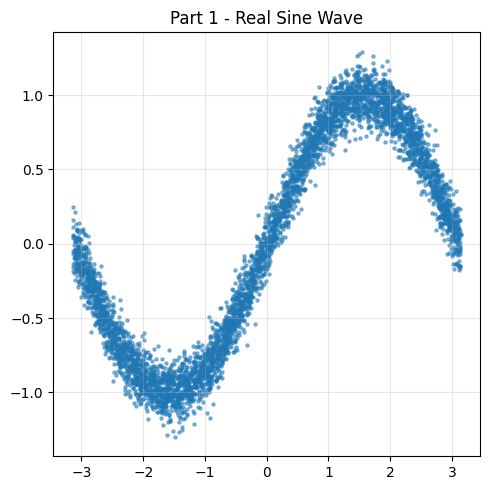

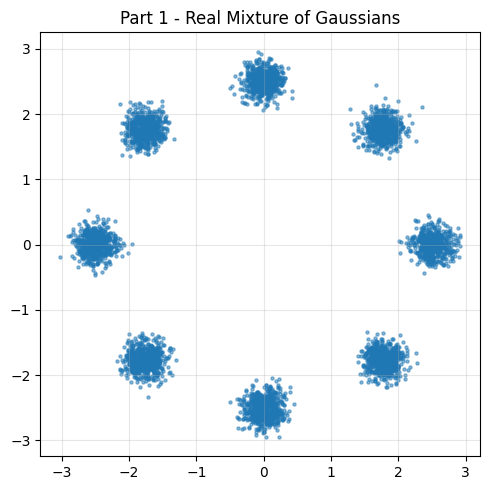

In [11]:
sine_data = make_sine_data()
mog_data = make_mog_data()

plot_2d_data(sine_data, "Part 1 - Real Sine Wave", "outputs/part1/sine_real.png")
plot_2d_data(mog_data, "Part 1 - Real Mixture of Gaussians", "outputs/part1/mog_real.png")

Epoch 1/200 | G: 0.7196 | D: 1.3491
Epoch 20/200 | G: 0.7146 | D: 1.3624
Epoch 40/200 | G: 0.7058 | D: 1.3760
Epoch 60/200 | G: 0.7089 | D: 1.3775
Epoch 80/200 | G: 0.7046 | D: 1.3811
Epoch 100/200 | G: 0.6994 | D: 1.3783
Epoch 120/200 | G: 0.7012 | D: 1.3790
Epoch 140/200 | G: 0.7002 | D: 1.3820
Epoch 160/200 | G: 0.6954 | D: 1.3830
Epoch 180/200 | G: 0.7009 | D: 1.3860
Epoch 200/200 | G: 0.6968 | D: 1.3887


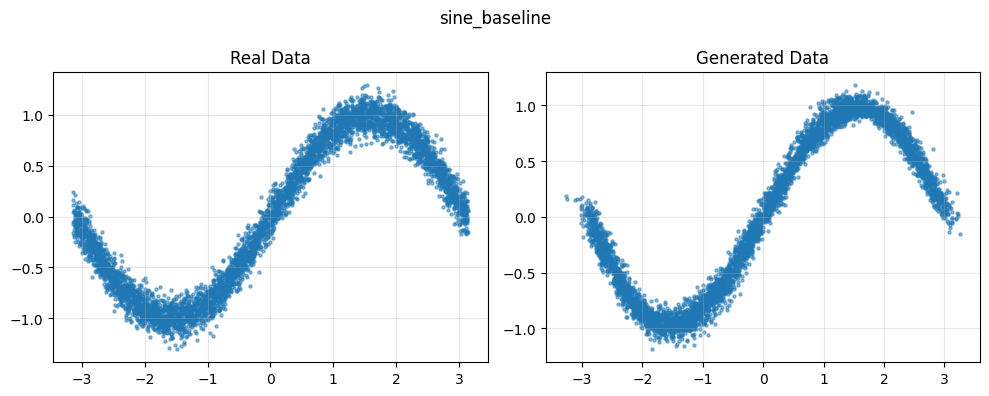

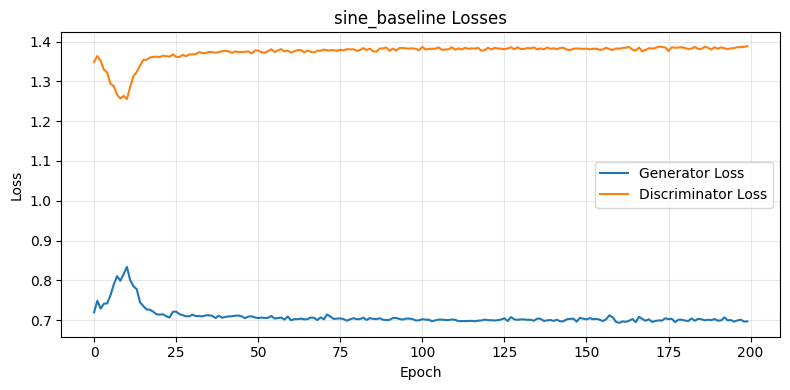

In [12]:
# 1) Reproduce sine-wave GAN
G_sine, D_sine, sine_g_losses, sine_d_losses, sine_fake = run_part1_experiment(
    data=sine_data,
    exp_name="sine_baseline",
    latent_dim=16,
    epochs=200,
    lr=2e-4,
    hidden_dims_g=(128, 256),
    hidden_dims_d=(256, 128),
    activation="leakyrelu",
    batch_norm=True
)

Epoch 1/200 | G: 0.6735 | D: 1.2914
Epoch 20/200 | G: 1.0933 | D: 1.0981
Epoch 40/200 | G: 1.2553 | D: 1.0172
Epoch 60/200 | G: 1.3940 | D: 0.9979
Epoch 80/200 | G: 1.4211 | D: 1.0342
Epoch 100/200 | G: 1.4665 | D: 1.0274
Epoch 120/200 | G: 1.4748 | D: 1.0570
Epoch 140/200 | G: 1.4122 | D: 1.0752
Epoch 160/200 | G: 1.3663 | D: 1.0976
Epoch 180/200 | G: 1.3546 | D: 1.1053
Epoch 200/200 | G: 1.3354 | D: 1.1060


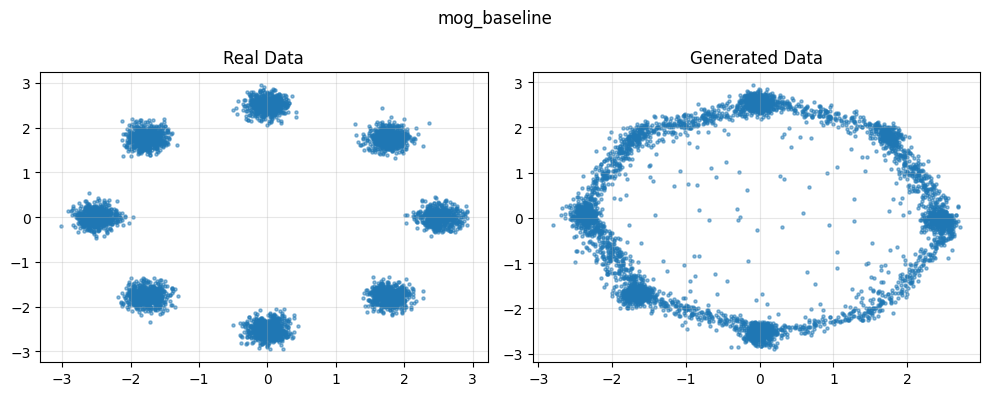

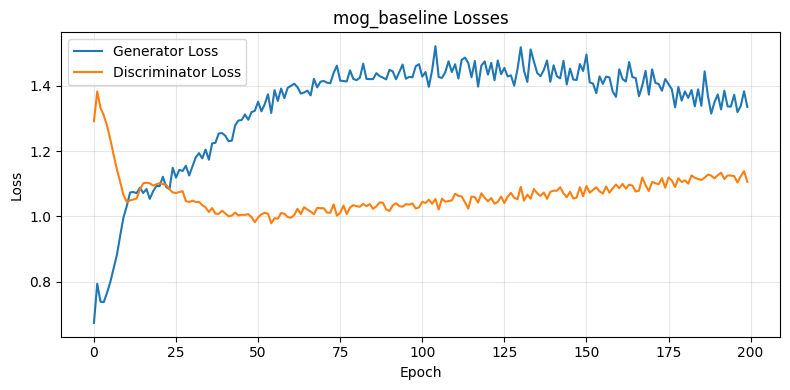

In [13]:
# 2) New 2D distribution: Mixture of Gaussians
G_mog_base, D_mog_base, mog_g_losses_base, mog_d_losses_base, mog_fake_base = run_part1_experiment(
    data=mog_data,
    exp_name="mog_baseline",
    latent_dim=16,
    epochs=200,
    lr=2e-4,
    hidden_dims_g=(128, 256),
    hidden_dims_d=(256, 128),
    activation="leakyrelu",
    batch_norm=True
)

Epoch 1/200 | G: 0.6723 | D: 1.2252
Epoch 20/200 | G: 1.2575 | D: 0.9713
Epoch 40/200 | G: 1.6189 | D: 0.8782
Epoch 60/200 | G: 1.8641 | D: 0.8606
Epoch 80/200 | G: 1.9763 | D: 0.8920
Epoch 100/200 | G: 1.9592 | D: 0.9518
Epoch 120/200 | G: 1.8966 | D: 0.9975
Epoch 140/200 | G: 1.8228 | D: 0.9957
Epoch 160/200 | G: 1.8424 | D: 1.0218
Epoch 180/200 | G: 1.7388 | D: 1.0370
Epoch 200/200 | G: 1.6826 | D: 1.0719


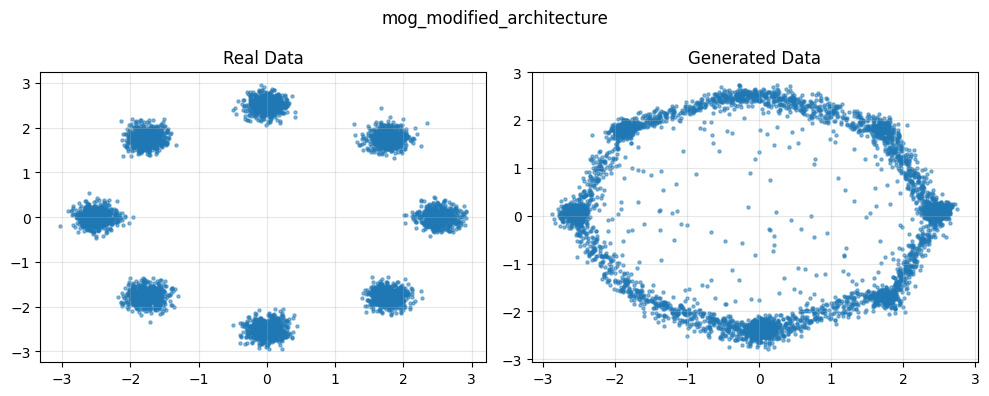

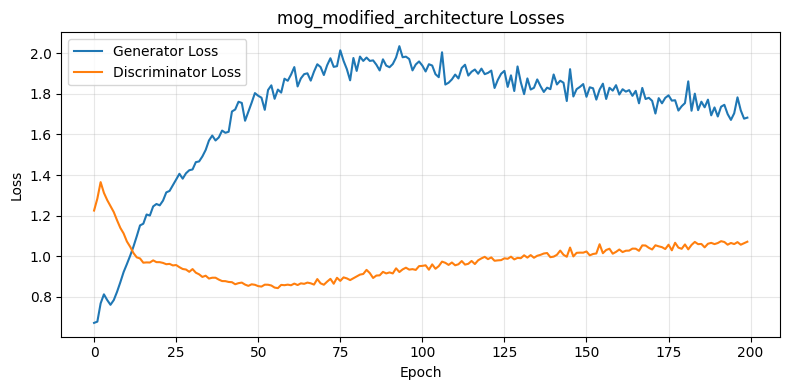

In [14]:
# 3) Modified architecture for comparison
G_mog_mod, D_mog_mod, mog_g_losses_mod, mog_d_losses_mod, mog_fake_mod = run_part1_experiment(
    data=mog_data,
    exp_name="mog_modified_architecture",
    latent_dim=32,
    epochs=200,
    lr=1e-4,
    hidden_dims_g=(256, 256),
    hidden_dims_d=(256, 256),
    activation="relu",
    batch_norm=True
)

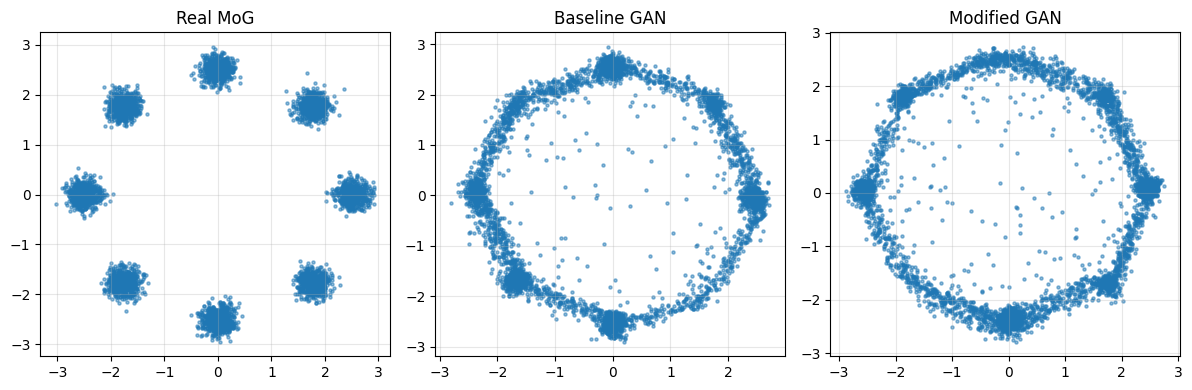

In [15]:
# Compare baseline vs modified architecture on MoG
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(mog_data[:, 0], mog_data[:, 1], s=5, alpha=0.5)
plt.title("Real MoG")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(mog_fake_base[:, 0], mog_fake_base[:, 1], s=5, alpha=0.5)
plt.title("Baseline GAN")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(mog_fake_mod[:, 0], mog_fake_mod[:, 1], s=5, alpha=0.5)
plt.title("Modified GAN")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/part1/mog_architecture_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

In [16]:
!wget https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pizza.npy -P data/quickdraw/

--2026-04-22 22:44:19--  https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pizza.npy
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.215.207, 173.194.216.207, 173.194.217.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.215.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 102210944 (97M) [application/octet-stream]
Saving to: ‘data/quickdraw/pizza.npy.1’

pizza.npy.1         100%[===================>]  97.48M   132MB/s    in 0.7s    

2026-04-22 22:44:20 (132 MB/s) - ‘data/quickdraw/pizza.npy.1’ saved [102210944/102210944]



## Loading Datasets

In [17]:
import os
print(os.listdir("data/quickdraw"))

['pizza.npy', 'pizza.npy.1']


In [18]:
import numpy as np

pizza = np.load("data/quickdraw/pizza.npy")
print(pizza.shape)

(130371, 784)


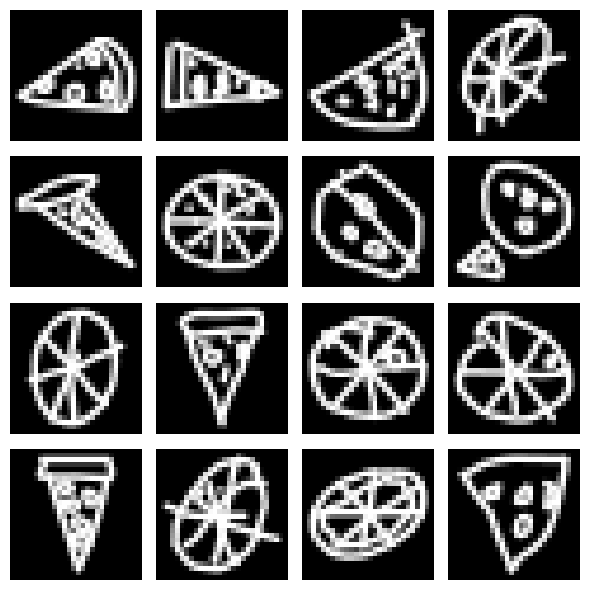

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(pizza[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv", low_memory=False)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print(df["Label"].value_counts().head())

Shape: (692703, 79)
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64


In [22]:
import os

cicids_path = "/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv"
quickdraw_path = "/content/data/quickdraw/pizza.npy"

print("CICIDS exists:", os.path.exists(cicids_path))
print("QuickDraw exists:", os.path.exists(quickdraw_path))

CICIDS exists: True
QuickDraw exists: True


## Part 2.1: BloodMNIST

This section applies a DCGAN to generate synthetic blood cell images.

The dataset is explored to understand class distribution. A DCGAN is trained and evaluated using loss curves, generated samples, and FID.

# Loading BloodMNIST

In [23]:
data_flag = "bloodmnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

blood_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

blood_train = DataClass(split="train", transform=blood_transform, download=True)
blood_val   = DataClass(split="val", transform=blood_transform, download=True)

blood_train_loader = DataLoader(blood_train, batch_size=128, shuffle=True)
blood_val_loader   = DataLoader(blood_val, batch_size=128, shuffle=False)

print("Train:", len(blood_train), "Val:", len(blood_val))

Train: 11959 Val: 1712


## Blood Samples

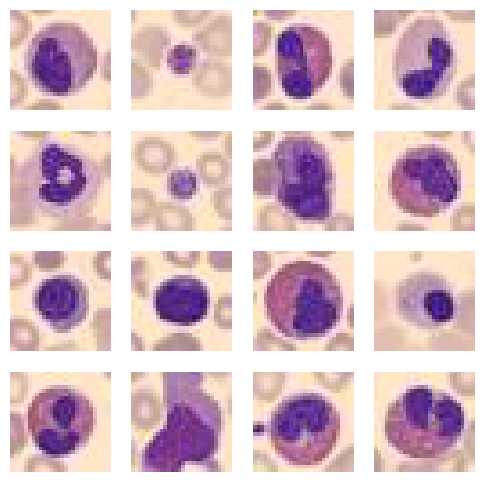

In [24]:
images, labels = next(iter(blood_train_loader))

plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    img = (images[i].permute(1,2,0).numpy()*0.5)+0.5
    plt.imshow(img)
    plt.axis("off")
plt.show()

# DCGAN Models

In [25]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100, channels=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim,256,7,1,0),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64,channels,3,1,1),
            nn.Tanh()
        )
    def forward(self,z): return self.net(z)

class DCDiscriminator(nn.Module):
    def __init__(self, channels=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128*7*7,1),
            nn.Sigmoid()
        )
    def forward(self,x): return self.net(x)

## Training DCGAN

In [26]:
def train_dcgan(G, D, loader, epochs=5, latent_dim=100):
    G, D = G.to(device), D.to(device)

    opt_g = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    loss_fn = nn.BCELoss()

    g_losses, d_losses = [], []

    print("Starting training...")
    print("Batches per epoch:", len(loader))

    for epoch in range(epochs):
        g_epoch, d_epoch = 0.0, 0.0

        for batch_idx, batch in enumerate(loader):
            real = batch[0].to(device)
            bs = real.size(0)

            real_lbl = torch.ones(bs, 1, device=device)
            fake_lbl = torch.zeros(bs, 1, device=device)

            z = torch.randn(bs, latent_dim, 1, 1, device=device)
            fake = G(z)

            loss_d = loss_fn(D(real), real_lbl) + loss_fn(D(fake.detach()), fake_lbl)
            opt_d.zero_grad()
            loss_d.backward()
            opt_d.step()

            z = torch.randn(bs, latent_dim, 1, 1, device=device)
            fake = G(z)
            loss_g = loss_fn(D(fake), real_lbl)

            opt_g.zero_grad()
            loss_g.backward()
            opt_g.step()

            g_epoch += loss_g.item()
            d_epoch += loss_d.item()

            if batch_idx == 0:
                print(f"Epoch {epoch+1} started...")

        g_losses.append(g_epoch / len(loader))
        d_losses.append(d_epoch / len(loader))

        print(f"Epoch {epoch+1}/{epochs} | G: {g_losses[-1]:.4f} | D: {d_losses[-1]:.4f}")

    return g_losses, d_losses

## Part 2.2: Cybersecurity GAN

A GAN is trained on tabular network traffic data (CICIDS 2017).

The model generates synthetic feature vectors. PCA and t-SNE are used to compare real and generated distributions.

# Load & Filter CICIDS

In [27]:
import pandas as pd

df = pd.read_csv(cicids_path, low_memory=False)
df.columns = df.columns.str.strip()

print(df["Label"].value_counts().head())

# Keep BENIGN + DoS attacks
attack_labels = [l for l in df["Label"].unique() if str(l).startswith("DoS")]

cicids_filtered = df[df["Label"].isin(["BENIGN"] + attack_labels)]
cicids_filtered = cicids_filtered.replace([np.inf,-np.inf],np.nan).dropna()

print("Filtered:", cicids_filtered.shape)

Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64
Filtered: (691395, 79)


## Preprocessing CICIDS

In [28]:
from sklearn.preprocessing import StandardScaler

num = cicids_filtered.select_dtypes(include=[np.number])
num = num.loc[:, num.nunique()>1]

X = StandardScaler().fit_transform(num)

X_tensor = torch.tensor(X, dtype=torch.float32)
loader = DataLoader(TensorDataset(X_tensor), batch_size=256, shuffle=True)

feature_dim = X.shape[1]

## CICIDS GAN

In [29]:
X_small = X[:100000]

X_tensor_small = torch.tensor(X_small, dtype=torch.float32)
loader_small = DataLoader(TensorDataset(X_tensor_small), batch_size=256, shuffle=True)

print("Small dataset shape:", X_small.shape)

Small dataset shape: (100000, 68)


In [30]:
latent_dim = 32

G_tab = MLPGenerator(latent_dim=latent_dim, output_dim=feature_dim)
D_tab = MLPDiscriminator(input_dim=feature_dim)

cicids_g_losses, cicids_d_losses = train_mlp_gan(
    G_tab,
    D_tab,
    loader_small,
    latent_dim=latent_dim,
    epochs=15,
    lr=2e-4,
    device=device
)

Epoch 1/15 | G: 0.7952 | D: 1.2215


## Generating fake data

In [31]:
@torch.no_grad()
def generate_tabular_samples(generator, n_samples, latent_dim, device):
    generator.eval()
    z = torch.randn(n_samples, latent_dim, device=device)
    fake = generator(z).cpu().numpy()
    generator.train()
    return fake

X_fake = generate_tabular_samples(G_tab.to(device), len(X), latent_dim, device)

print("Fake shape:", X_fake.shape)

Fake shape: (691395, 68)


# PCA

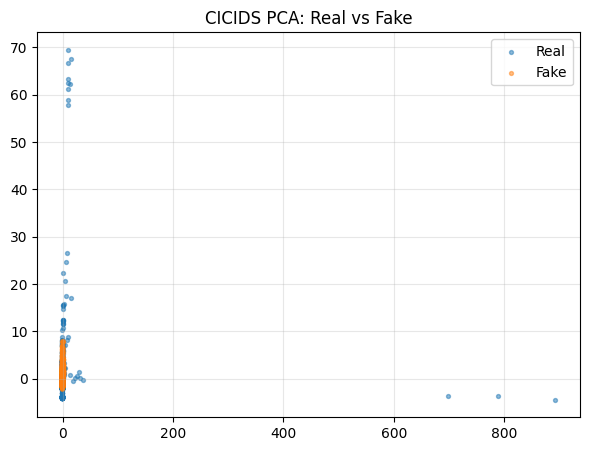

In [32]:

from sklearn.decomposition import PCA

n_samples = 2000
real = X[:n_samples]
fake = X_fake[:n_samples]

combined = np.vstack([real, fake])

pca = PCA(n_components=2)
reduced = pca.fit_transform(combined)

real_2d = reduced[:len(real)]
fake_2d = reduced[len(real):]

plt.figure(figsize=(7,5))
plt.scatter(real_2d[:,0], real_2d[:,1], s=8, alpha=0.5, label="Real")
plt.scatter(fake_2d[:,0], fake_2d[:,1], s=8, alpha=0.5, label="Fake")

plt.title("CICIDS PCA: Real vs Fake")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# t-SNE

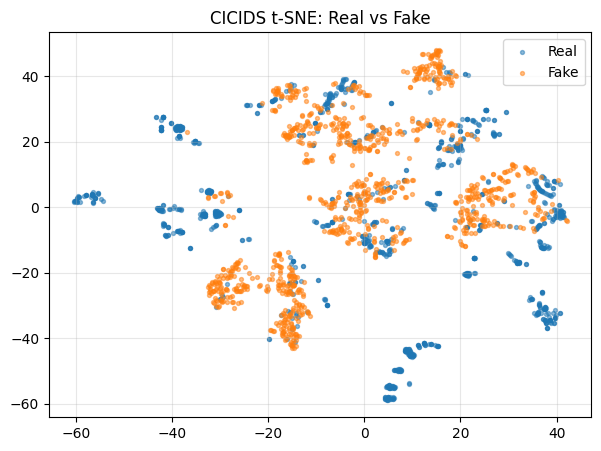

In [33]:
from sklearn.manifold import TSNE

n_samples = 1000
real = X[:n_samples]
fake = X_fake[:n_samples]

combined = np.vstack([real, fake])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb = tsne.fit_transform(combined)

real_2d = emb[:len(real)]
fake_2d = emb[len(real):]

plt.figure(figsize=(7,5))
plt.scatter(real_2d[:,0], real_2d[:,1], s=8, alpha=0.5, label="Real")
plt.scatter(fake_2d[:,0], fake_2d[:,1], s=8, alpha=0.5, label="Fake")

plt.title("CICIDS t-SNE: Real vs Fake")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
cicids_numeric = cicids_filtered.select_dtypes(include=[np.number]).copy()
cicids_numeric = cicids_numeric.loc[:, cicids_numeric.nunique() > 1]

print("Recreated cicids_numeric:", cicids_numeric.shape)

Recreated cicids_numeric: (691395, 68)


# Feature distribution comparison

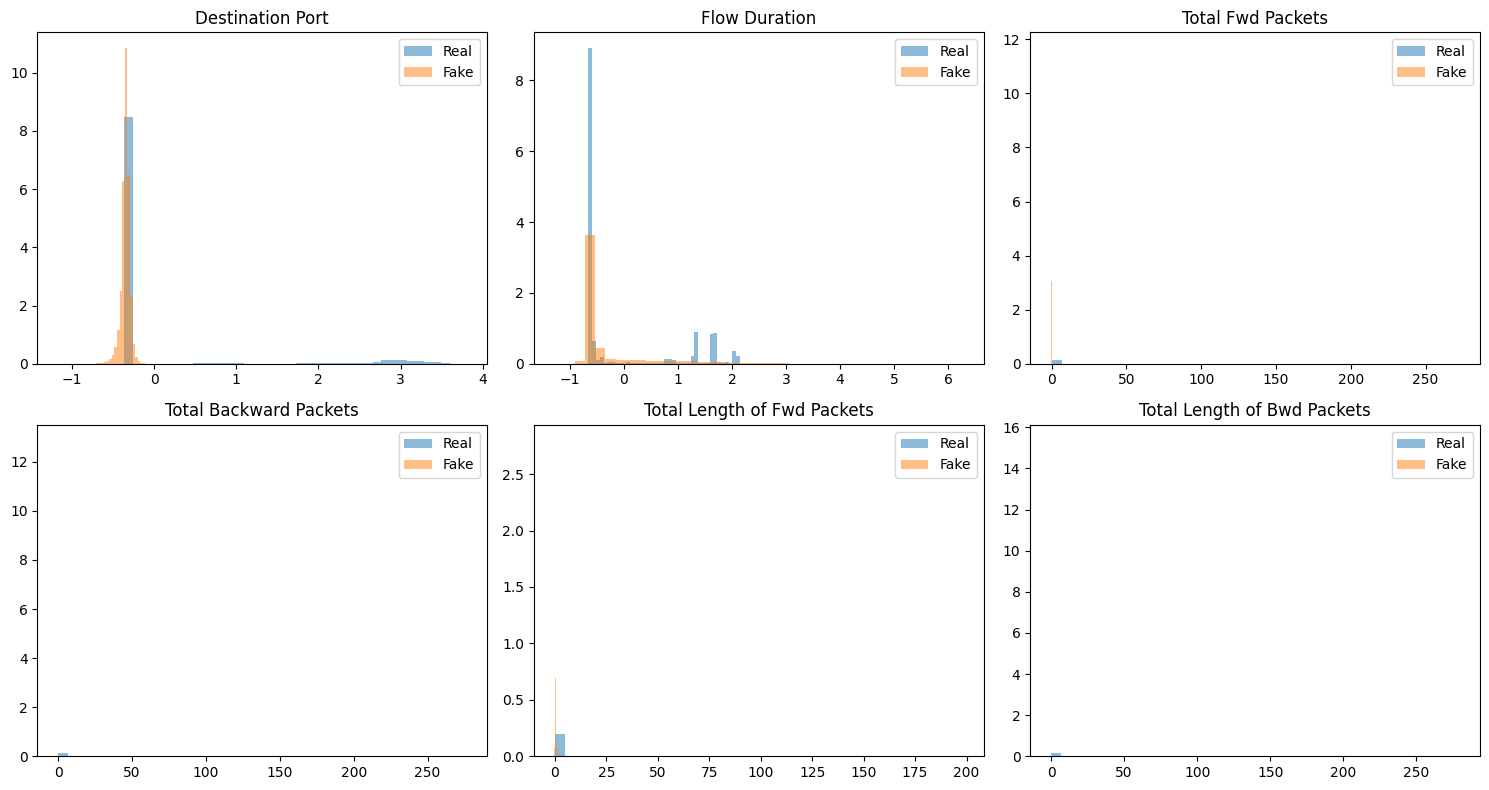

In [35]:
feature_names = cicids_numeric.columns.tolist()[:6]

plt.figure(figsize=(15,8))

for i, feat in enumerate(feature_names, start=1):
    plt.subplot(2,3,i)
    plt.hist(X[:,i-1], bins=40, alpha=0.5, label="Real", density=True)
    plt.hist(X_fake[:,i-1], bins=40, alpha=0.5, label="Fake", density=True)
    plt.title(feat)
    plt.legend()

plt.tight_layout()
plt.show()

# Summary Table

In [36]:
cicids_summary = pd.DataFrame({
    "dataset": ["CICIDS Wednesday"],
    "rows_used": [len(X)],
    "features": [feature_dim],
    "labels_used": ["BENIGN + DoS attacks"]
})

cicids_summary

,dataset,rows_used,features,labels_used
0,CICIDS Wednesday,691395,68,BENIGN + DoS attacks


## Part 2.3: Creative AI (QuickDraw)

A DCGAN is trained on sketch data to generate synthetic pizza drawings.

Generated outputs are evaluated visually and using FID.

# Loading QuickDraw

In [37]:
quickdraw_path = "/content/data/quickdraw/pizza.npy"

pizza = np.load(quickdraw_path).astype("float32")
print("Raw shape:", pizza.shape)

if pizza.ndim != 2 or pizza.shape[1] != 784:
    raise ValueError(f"Expected shape (N, 784), got {pizza.shape}")

pizza = pizza / 255.0
pizza = (pizza - 0.5) / 0.5
pizza = pizza.reshape(-1, 1, 28, 28)

pizza_tensor = torch.tensor(pizza, dtype=torch.float32)
pizza_loader = DataLoader(TensorDataset(pizza_tensor), batch_size=128, shuffle=True)

print("Processed shape:", pizza.shape)

Raw shape: (130371, 784)
Processed shape: (130371, 1, 28, 28)


## QuickDraw samples

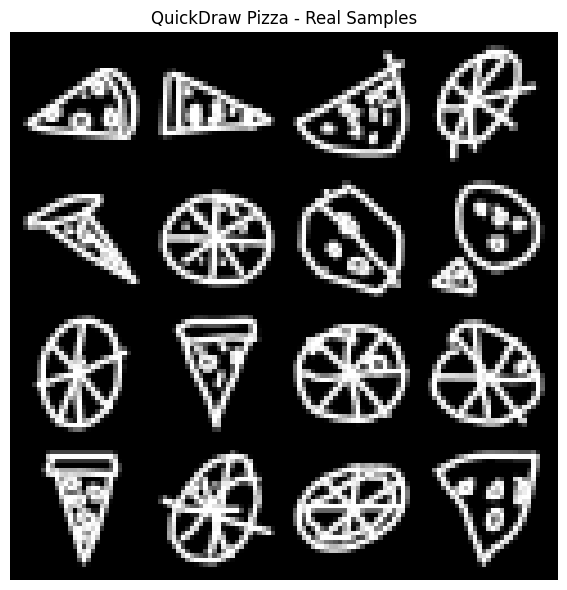

In [38]:
real_pizza = pizza_tensor[:16]
save_or_show_grid(
    real_pizza,
    title="QuickDraw Pizza - Real Samples",
    save_path="outputs/quickdraw/real_samples.png",
    nrow=4,
    normalize=True,
    cmap="gray"
)

In [39]:
pizza_small = pizza[:10000]
pizza_small_tensor = torch.tensor(pizza_small, dtype=torch.float32)
pizza_small_loader = DataLoader(TensorDataset(pizza_small_tensor), batch_size=64, shuffle=True)

print("QuickDraw subset shape:", pizza_small.shape)

QuickDraw subset shape: (10000, 1, 28, 28)


## QuickDraw GAN Train

In [40]:
G_quick = DCGenerator(latent_dim=100, channels=1)
D_quick = DCDiscriminator(channels=1)

quick_g_losses, quick_d_losses = train_dcgan(
    G_quick,
    D_quick,
    pizza_small_loader,
    epochs=5,
    latent_dim=100
)

Starting training...
Batches per epoch: 157
Epoch 1 started...
Epoch 1/5 | G: 1.1051 | D: 1.1906
Epoch 2 started...
Epoch 2/5 | G: 0.9877 | D: 1.1151
Epoch 3 started...
Epoch 3/5 | G: 1.2134 | D: 0.9453
Epoch 4 started...
Epoch 4/5 | G: 1.3107 | D: 0.8234
Epoch 5 started...
Epoch 5/5 | G: 1.4742 | D: 0.7330


## QuickDraw losses

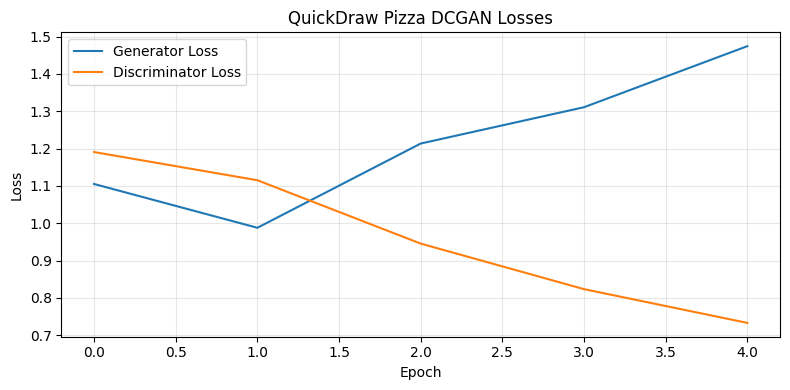

In [41]:
save_loss_plot(
    quick_g_losses,
    quick_d_losses,
    title="QuickDraw Pizza DCGAN Losses",
    save_path="outputs/quickdraw/losses.png"
)

In [42]:
def save_generated_grid(generator, save_path, latent_dim=100, n=16, device="cpu", title="Generated Samples", cmap=None):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n, latent_dim, 1, 1, device=device)
        fake = generator(z).cpu()

    grid = make_grid(fake, nrow=4, normalize=True)
    arr = grid.permute(1, 2, 0).numpy()

    plt.figure(figsize=(6,6))
    if arr.shape[-1] == 1:
        plt.imshow(arr.squeeze(), cmap=cmap or "gray")
    else:
        plt.imshow(arr)
    plt.title(title)
    plt.axis("off")

    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

## QuickDraw Generated Samples

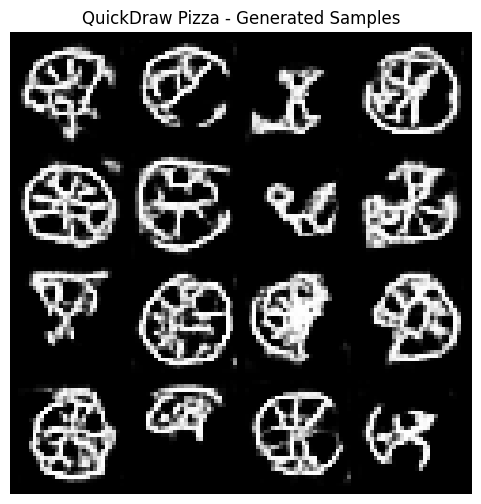

In [43]:
save_generated_grid(
    G_quick.to(device),
    save_path="outputs/quickdraw/generated_samples.png",
    latent_dim=100,
    n=16,
    device=device,
    title="QuickDraw Pizza - Generated Samples",
    cmap="gray"
)

## QuickDraw FID

In [44]:
small_loader = DataLoader(
    TensorDataset(torch.tensor(pizza[:1000], dtype=torch.float32)),
    batch_size=64,
    shuffle=False
)

quick_fid = compute_fid(
    generator=G_quick.to(device),
    real_loader=small_loader,
    latent_dim=100,
    device=device,
    is_rgb=False,
    max_batches=1
)

print("QuickDraw FID:", quick_fid)

QuickDraw FID: 116.16327667236328


## QuickDraw summary

In [45]:
quickdraw_summary = pd.DataFrame({
    "dataset": ["QuickDraw Pizza"],
    "samples_used": [1000],
    "image_shape": ["1 x 28 x 28"],
    "fid": [quick_fid]
})
quickdraw_summary

,dataset,samples_used,image_shape,fid
0,QuickDraw Pizza,1000,1 x 28 x 28,116.163277


## BloodMNIST load

In [46]:
data_flag = "bloodmnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

blood_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

blood_train = DataClass(split="train", transform=blood_transform, download=True)
blood_val   = DataClass(split="val", transform=blood_transform, download=True)
blood_test  = DataClass(split="test", transform=blood_transform, download=True)

blood_train_loader = DataLoader(blood_train, batch_size=128, shuffle=True)
blood_val_loader   = DataLoader(blood_val, batch_size=128, shuffle=False)
blood_test_loader  = DataLoader(blood_test, batch_size=128, shuffle=False)

print("BloodMNIST labels:", info["label"])
print("Train:", len(blood_train), "Val:", len(blood_val), "Test:", len(blood_test))

BloodMNIST labels: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
Train: 11959 Val: 1712 Test: 3421


## BloodMNIST Samples

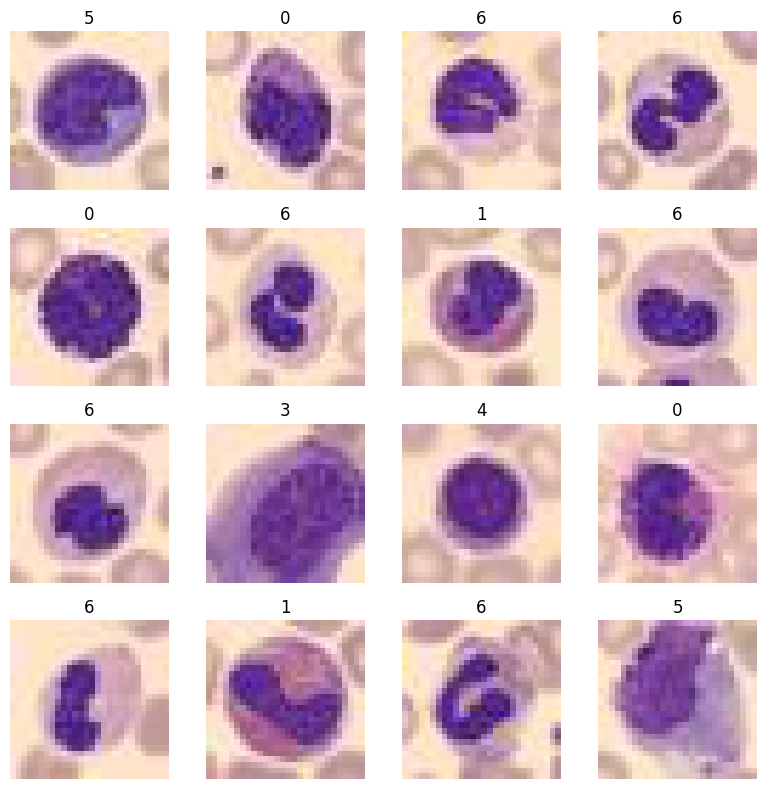

In [47]:
images, labels = next(iter(blood_train_loader))

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5
    plt.imshow(img)
    plt.title(str(int(labels[i])))
    plt.axis("off")
plt.tight_layout()
plt.savefig("outputs/bloodmnist/real_samples.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

## BloodMNIST class distribution

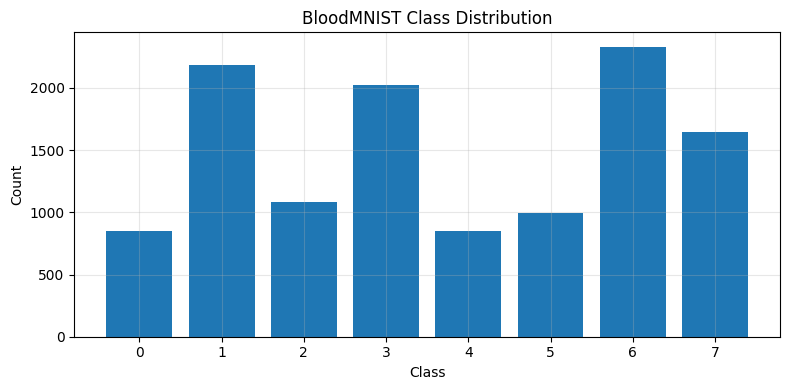

,count
0,852
1,2181
2,1085
3,2026
4,849
5,993
6,2330
7,1643


In [48]:
blood_labels = [int(y) for _, y in blood_train]
blood_counts = pd.Series(blood_labels).value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(blood_counts.index, blood_counts.values)
plt.title("BloodMNIST Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/bloodmnist/class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

blood_counts

## BloodMNIST experiment runner

In [51]:
def run_blood_experiment(exp_name, batch_size=128, latent_dim=100, epochs=10):
    train_loader = DataLoader(blood_train, batch_size=batch_size, shuffle=True)


    G = DCGenerator(latent_dim=latent_dim, channels=3)
    D = DCDiscriminator(channels=3)

    g_losses, d_losses = train_dcgan(
        G,
        D,
        train_loader,
        epochs=epochs,
        latent_dim=latent_dim
    )

    save_loss_plot(
        g_losses,
        d_losses,
        title=f"BloodMNIST - {exp_name} Losses",
        save_path=f"outputs/bloodmnist/{exp_name}_losses.png"
    )

    save_generated_grid(
        G.to(device),
        save_path=f"outputs/bloodmnist/{exp_name}_generated.png",
        latent_dim=latent_dim,
        n=16,
        device=device,
        title=f"BloodMNIST - {exp_name}"
    )


    fid_score = compute_fid(
        generator=G.to(device),
        real_loader=blood_val_loader,
        latent_dim=latent_dim,
        device=device,
        is_rgb=True,
        max_batches=3
    )

    print(f"{exp_name} FID: {fid_score:.4f}")

    return {
        "experiment": exp_name,
        "batch_size": batch_size,
        "latent_dim": latent_dim,
        "epochs": epochs,
        "fid": fid_score,
        "g_final": g_losses[-1],
        "d_final": d_losses[-1]
    }

## BloodMNIST tuning runs

Starting training...
Batches per epoch: 94
Epoch 1 started...
Epoch 1/5 | G: 0.9911 | D: 1.4098
Epoch 2 started...
Epoch 2/5 | G: 0.9055 | D: 1.4303
Epoch 3 started...
Epoch 3/5 | G: 0.8273 | D: 1.4586
Epoch 4 started...
Epoch 4/5 | G: 0.8413 | D: 1.4556
Epoch 5 started...
Epoch 5/5 | G: 0.8038 | D: 1.4418


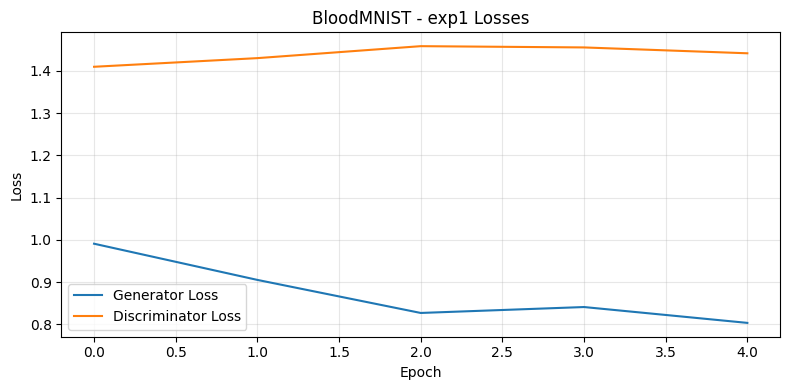

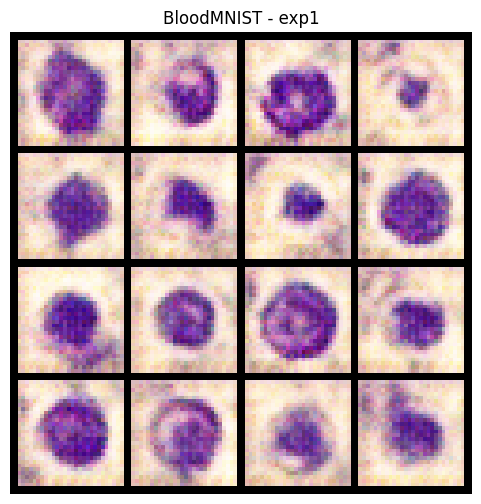

exp1 FID: 380.7888
Starting training...
Batches per epoch: 187
Epoch 1 started...
Epoch 1/5 | G: 0.9970 | D: 1.3611
Epoch 2 started...
Epoch 2/5 | G: 0.8210 | D: 1.4153
Epoch 3 started...
Epoch 3/5 | G: 0.8429 | D: 1.4070
Epoch 4 started...
Epoch 4/5 | G: 0.8128 | D: 1.4064
Epoch 5 started...
Epoch 5/5 | G: 0.7897 | D: 1.3955


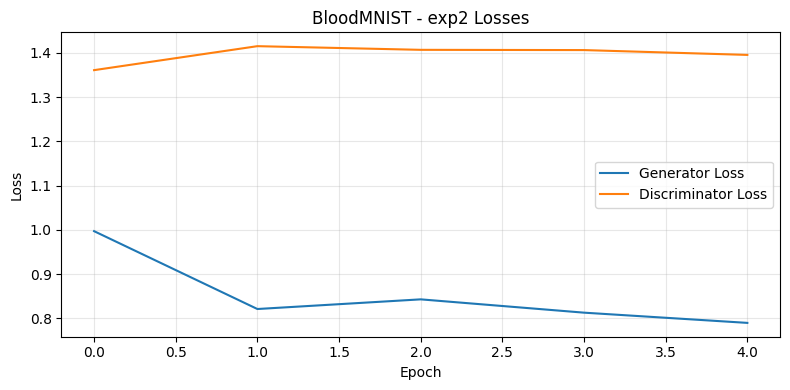

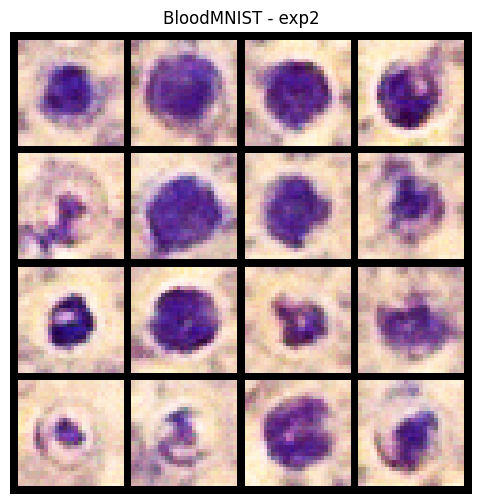

exp2 FID: 361.5753


In [52]:
blood_results = []

blood_results.append(run_blood_experiment(
    exp_name="exp1",
    batch_size=128,
    latent_dim=100,
    epochs=5
))

blood_results.append(run_blood_experiment(
    exp_name="exp2",
    batch_size=64,
    latent_dim=100,
    epochs=5
))

## BloodMNIST results table

In [53]:
blood_results_df = pd.DataFrame(blood_results).sort_values("fid")
blood_results_df.to_csv("outputs/bloodmnist/hyperparameter_results.csv", index=False)
blood_results_df

,experiment,batch_size,latent_dim,epochs,fid,g_final,d_final
1,exp2,64,100,5,361.575256,0.789661,1.395522
0,exp1,128,100,5,380.788788,0.803777,1.441769


## final overall summary

In [54]:
part1_summary = pd.DataFrame({
    "experiment": ["sine_baseline", "mog_baseline", "mog_modified_architecture"],
    "status": ["done", "done", "done"]
})

print("PART 1")
display(part1_summary)

print("CICIDS")
display(cicids_summary)

print("QUICKDRAW")
display(quickdraw_summary)

print("BLOODMNIST")
display(blood_results_df)

PART 1


,experiment,status
0,sine_baseline,done
1,mog_baseline,done
2,mog_modified_architecture,done


CICIDS


,dataset,rows_used,features,labels_used
0,CICIDS Wednesday,691395,68,BENIGN + DoS attacks


QUICKDRAW


,dataset,samples_used,image_shape,fid
0,QuickDraw Pizza,1000,1 x 28 x 28,116.163277


BLOODMNIST


,experiment,batch_size,latent_dim,epochs,fid,g_final,d_final
1,exp2,64,100,5,361.575256,0.789661,1.395522
0,exp1,128,100,5,380.788788,0.803777,1.441769


## Conclusion

The experiments demonstrate that GANs are effective for generating simple synthetic and image-based data, but struggle with high-dimensional tabular data such as CICIDS.

The results highlight:
- strong performance on low-dimensional and visual data
- instability and mode collapse in tabular GANs
- importance of hyperparameter tuning

Future work could include:
- conditional GANs
- improved architectures (WGAN, StyleGAN)
- larger training resources

In [55]:
import os

for folder in ["outputs/part1", "outputs/bloodmnist", "outputs/cicids", "outputs/quickdraw"]:
    print("\n", folder)
    if os.path.exists(folder):
        print(os.listdir(folder))
    else:
        print("Folder not found")


 outputs/part1
['mog_modified_architecture_real_vs_fake.png', 'sine_baseline_losses.png', 'mog_architecture_comparison.png', 'mog_baseline_real_vs_fake.png', 'mog_baseline_losses.png', 'mog_real.png', 'sine_baseline_real_vs_fake.png', 'mog_modified_architecture_losses.png', 'sine_real.png']

 outputs/bloodmnist
['exp2_losses.png', 'hyperparameter_results.csv', 'class_distribution.png', 'exp1_losses.png', 'exp1_generated.png', 'real_samples.png', 'exp2_generated.png']

 outputs/cicids
[]

 outputs/quickdraw
['generated_samples.png', 'losses.png', 'real_samples.png']
